<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/model_hybrid_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip -q install wordcloud

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use('ggplot')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [15]:
url = "https://raw.githubusercontent.com/Light466/My_Programs/main/symptoms_dataset.csv"

df = pd.read_csv(url)

print("="*80)
print("Dataset Loaded Successfully")
print("="*80)

print("Dataset Shape :", df.shape)

Dataset Loaded Successfully
Dataset Shape : (10700, 2)


In [16]:
df.head(10)

,Symptoms,Disease
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS)
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV)
2,nausea fatigue sometimes diarrhea or jaundice,Malaria
3,contractions Heavy vaginal bleeding,Late Miscarriage
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy
5,need for order or symmetry anxiety distress wh...,Obsessive Compulsive Disorder (OCD)
6,fatigue headache Fever in severe cases paralys...,Polio (Poliomyelitis)
7,irritability difficulty concentrating racing t...,Mental Anxiety Disorder
8,abdominal cramps bloating Frequent loose or wa...,Diarrhoea
9,Headaches blurred vision red or flushed skin f...,Polycythemia Vera


In [17]:
df.tail(10)

,Symptoms,Disease
10690,a feeling of something stuck in the throat dif...,Tonsil Stones
10691,sore throat nausea fatigue stomach pain muscle...,Polio (Poliomyelitis)
10692,snoring or sleep problems low energy fatigue d...,Obesity in Adults
10693,discomfort spreading to arm or back,Heart Disease
10694,fatigue or symptoms depending on tumour locati...,Rare Tumours
10695,blurred vision Headaches fatigue difficulty co...,Post-Concussion Syndrome (PCS)
10696,fatigue digestive problems such as bloating or...,Pancreatic Cancer
10697,persistent itching or burning foul-smelling di...,Penile Cancer
10698,confusion about time or place poor judgment,Alzheimer’s Disease
10699,limited movement of the affected area or trunk...,Soft Tissue Sarcomas in Teenagers and Young Ad...


In [18]:
df.columns = ["Symptoms","Disease"]

df.head()

,Symptoms,Disease
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS)
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV)
2,nausea fatigue sometimes diarrhea or jaundice,Malaria
3,contractions Heavy vaginal bleeding,Late Miscarriage
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy


In [19]:
print("="*80)
print("Dataset Information")
print("="*80)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10700 entries, 0 to 10699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Symptoms  10700 non-null  object
 1   Disease   10700 non-null  object
dtypes: object(2)
memory usage: 167.3+ KB


In [20]:
print("="*80)
print("Missing Values")
print("="*80)

print(df.isnull().sum())

Missing Values
Symptoms    0
Disease     0
dtype: int64


In [21]:
df.dropna(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (10700, 2)


In [22]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 309


In [23]:
df.drop_duplicates(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (10391, 2)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10391 entries, 0 to 10699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Symptoms  10391 non-null  object
 1   Disease   10391 non-null  object
dtypes: object(2)
memory usage: 243.5+ KB


In [26]:
df.describe(include='all')

,Symptoms,Disease
count,10391,10391
unique,10355,207
top,dizziness fatigue,Insomnia
freq,3,100


In [27]:
print("="*80)
print("Total Disease Classes")
print("="*80)

print(df["Disease"].nunique())

Total Disease Classes
207


In [28]:
disease_counts = df["Disease"].value_counts()

print(disease_counts)

Disease
Insomnia                                           100
Pneumonia                                          100
Iron Deficiency Anemia                              99
Delirium                                            99
Skin and Scalp Psoriasis                            99
                                                  ... 
Muscular Back Strain                                43
Mouth Ulcer                                         36
Recurrent Miscarriage                               36
Prenatal Aneuploidy Screening (First Trimester)     12
High Cholesterol                                    11
Name: count, Length: 207, dtype: int64


In [29]:
disease_counts = df["Disease"].value_counts()

print(disease_counts)

Disease
Insomnia                                           100
Pneumonia                                          100
Iron Deficiency Anemia                              99
Delirium                                            99
Skin and Scalp Psoriasis                            99
                                                  ... 
Muscular Back Strain                                43
Mouth Ulcer                                         36
Recurrent Miscarriage                               36
Prenatal Aneuploidy Screening (First Trimester)     12
High Cholesterol                                    11
Name: count, Length: 207, dtype: int64


In [30]:
top20 = disease_counts.head(20)

top20

,count
Disease,
Insomnia,100
Pneumonia,100
Iron Deficiency Anemia,99
Delirium,99
Skin and Scalp Psoriasis,99
Influenza,98
Common cold,98
Panic Disorder,50
Polymyalgia Rheumatica (PMR),50


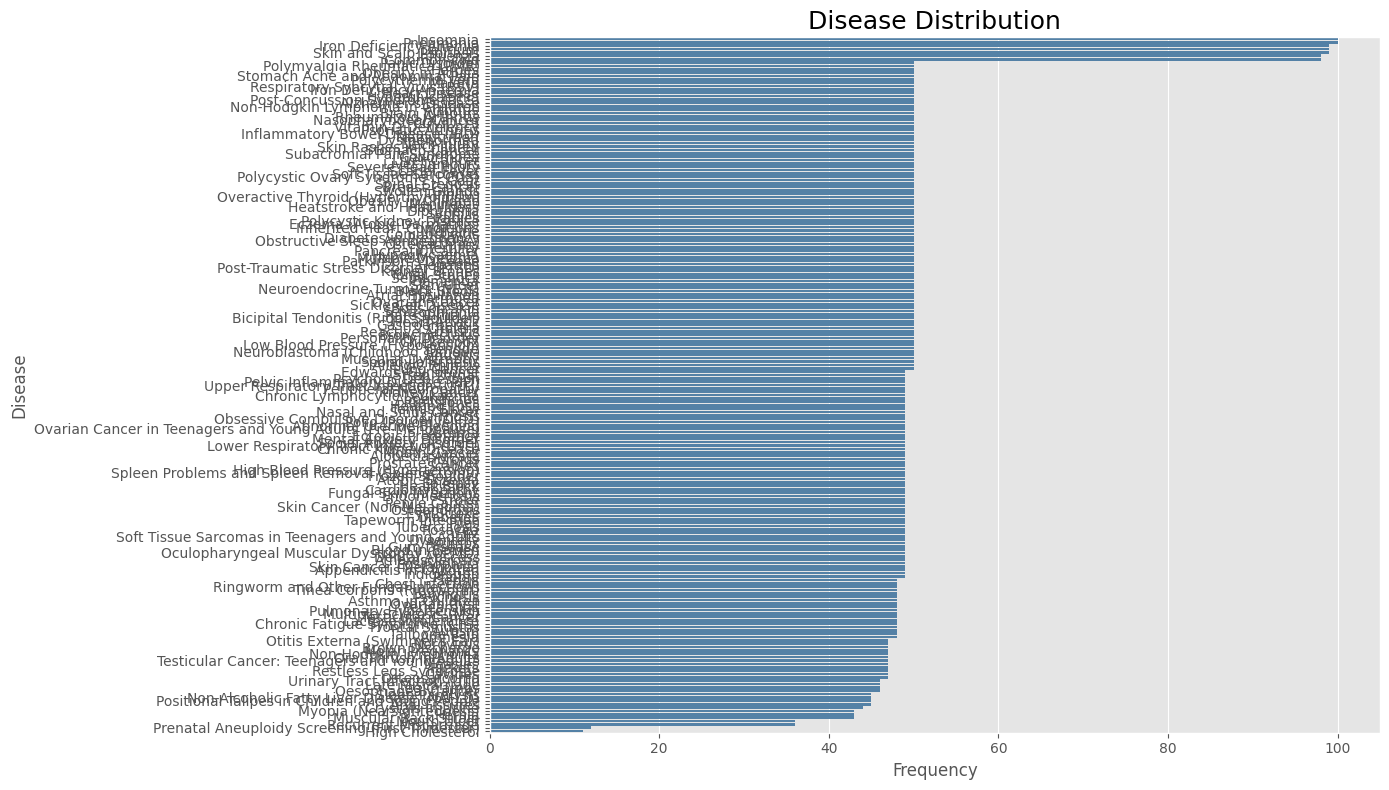

In [31]:
plt.figure(figsize=(14,8))

sns.countplot(
    y=df["Disease"],
    order=df["Disease"].value_counts().index,
    color="steelblue"
)

plt.title("Disease Distribution", fontsize=18)

plt.xlabel("Frequency")

plt.ylabel("Disease")

plt.tight_layout()

plt.show()

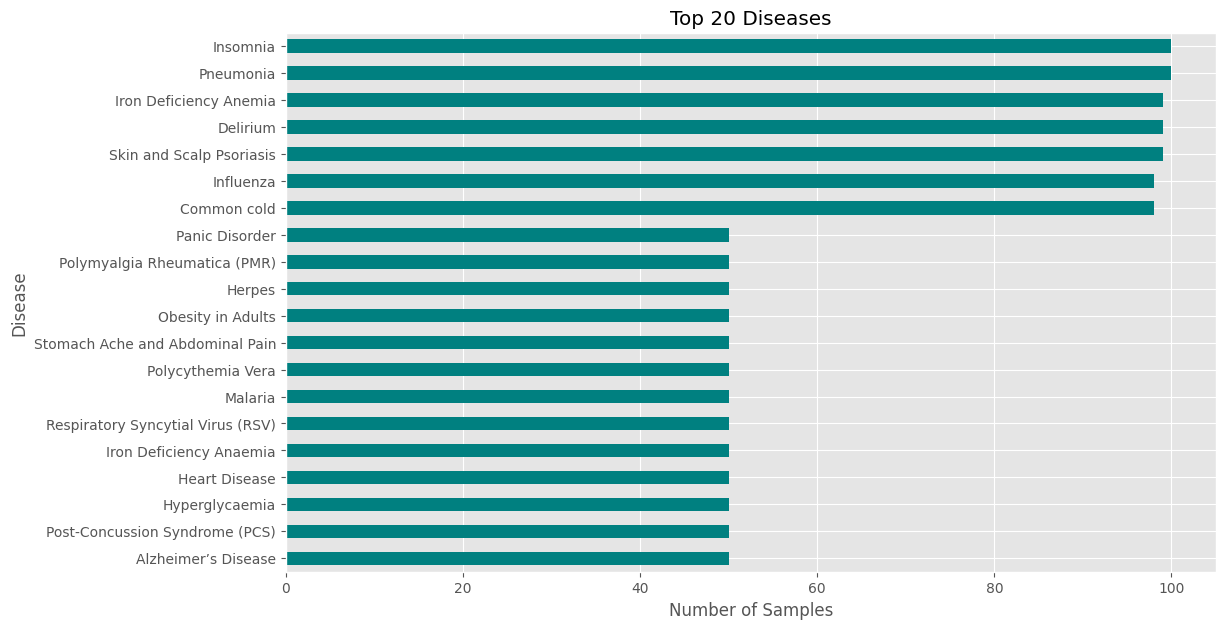

In [32]:
plt.figure(figsize=(12,7))

top20.plot(
    kind="barh",
    color="teal"
)

plt.xlabel("Number of Samples")

plt.title("Top 20 Diseases")

plt.gca().invert_yaxis()

plt.show()

In [33]:
df["Length"] = df["Symptoms"].apply(len)

df.head()

,Symptoms,Disease,Length
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45
3,contractions Heavy vaginal bleeding,Late Miscarriage,35
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95


In [34]:
print(df["Length"].describe())

count    10391.000000
mean        99.337311
std         46.966009
min          8.000000
25%         62.000000
50%         97.000000
75%        133.000000
max        268.000000
Name: Length, dtype: float64


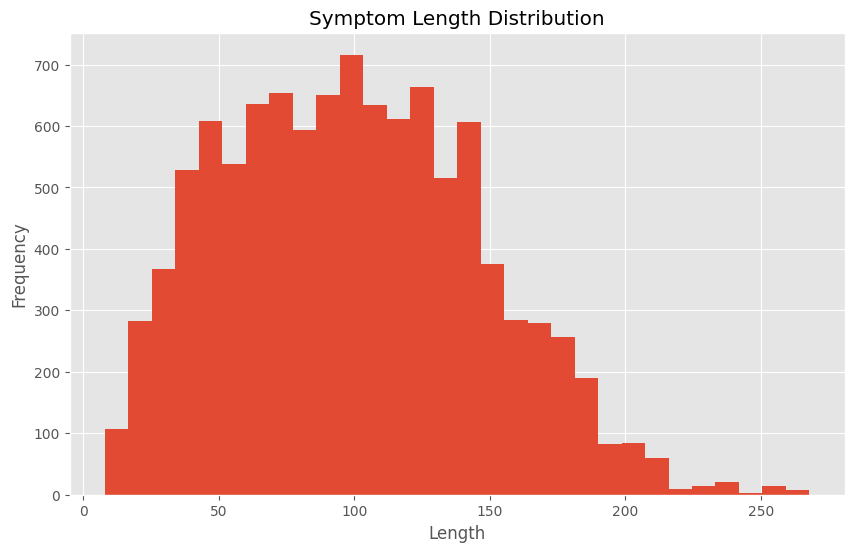

In [35]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Length"],
    bins=30
)

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.title("Symptom Length Distribution")

plt.show()

In [36]:
print(df["Disease"].value_counts().describe())

count    207.000000
mean      50.198068
std       10.036071
min       11.000000
25%       49.000000
50%       49.000000
75%       50.000000
max      100.000000
Name: count, dtype: float64


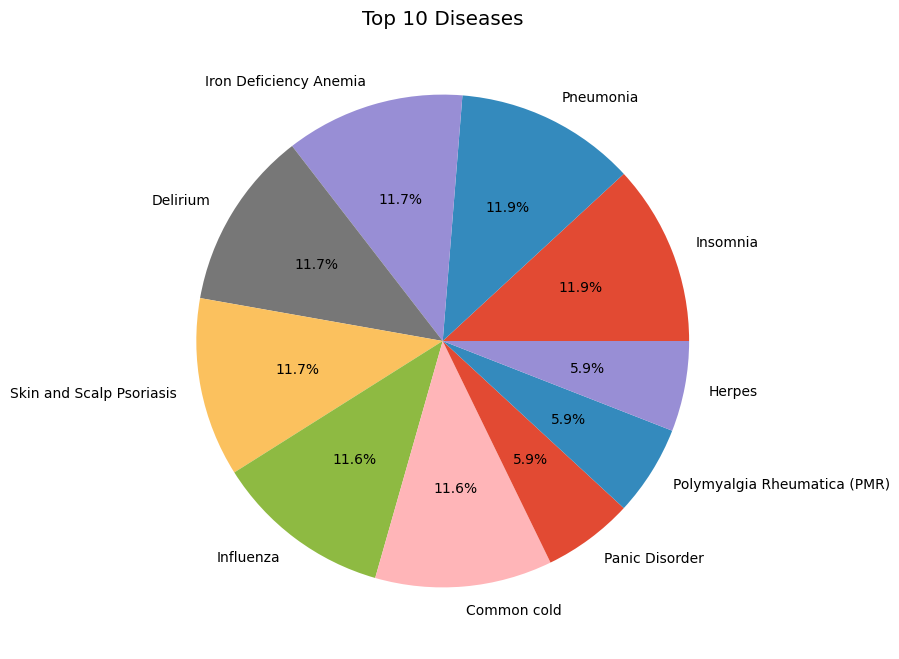

In [37]:
plt.figure(figsize=(8,8))

df["Disease"].value_counts().head(10).plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Top 10 Diseases")

plt.show()

In [38]:
duplicates = df.groupby("Symptoms")["Disease"].nunique()

ambiguous = duplicates[duplicates > 1]

print("Ambiguous Symptom Records:", len(ambiguous))

ambiguous.head(20)

Ambiguous Symptom Records: 31


,Disease
Symptoms,
Fever fatigue,2
Increased thirst fatigue,2
Wheezing chest tightness,2
dark urine loss of appetite,2
dizziness fatigue,3
fatigue abdominal swelling,2
fatigue blurred vision,2
fatigue fever,2
fatigue loss of appetite,2


In [39]:
print("="*80)
print("Dataset Summary")
print("="*80)

print("Total Samples :", len(df))

print("Total Diseases :", df["Disease"].nunique())

print("Duplicate Records :", duplicates.sum())

print("Missing Values :")

print(df.isnull().sum())

print("="*80)

Dataset Summary
Total Samples : 10391
Total Diseases : 207
Duplicate Records : 10391
Missing Values :
Symptoms    0
Disease     0
Length      0
dtype: int64


In [40]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Libraries Loaded Successfully")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Libraries Loaded Successfully


In [41]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    cleaned = []

    for word in words:

        if word not in stop_words:

            cleaned.append(

                lemmatizer.lemmatize(word)

            )

    return " ".join(cleaned)

In [42]:
df["Clean_Symptoms"] = df["Symptoms"].apply(clean_text)

print(df[["Symptoms","Clean_Symptoms"]].head())

                                            Symptoms  \
0  fatigue Numbness or tingling bladder problems ...   
1  Runny nose wheezing decreased appetite irritab...   
2      nausea fatigue sometimes diarrhea or jaundice   
3                contractions Heavy vaginal bleeding   
4  dizziness symptoms of early pregnancy such as ...   

                                      Clean_Symptoms  
0  fatigue numbness tingling bladder problem cogn...  
1  runny nose wheezing decreased appetite irritab...  
2         nausea fatigue sometimes diarrhea jaundice  
3                 contraction heavy vaginal bleeding  
4  dizziness symptom early pregnancy missed perio...  


In [43]:
for i in range(5):

    print("="*80)

    print("Original :")

    print(df["Symptoms"].iloc[i])

    print()

    print("Cleaned :")

    print(df["Clean_Symptoms"].iloc[i])

Original :
fatigue Numbness or tingling bladder problems cognitive difficulties dizziness difficulty walking muscle weakness vision problems

Cleaned :
fatigue numbness tingling bladder problem cognitive difficulty dizziness difficulty walking muscle weakness vision problem
Original :
Runny nose wheezing decreased appetite irritability in infants rapid or difficult breathing sneezing fever cough sometimes bluish lips or nails in severe cases

Cleaned :
runny nose wheezing decreased appetite irritability infant rapid difficult breathing sneezing fever cough sometimes bluish lip nail severe case
Original :
nausea fatigue sometimes diarrhea or jaundice

Cleaned :
nausea fatigue sometimes diarrhea jaundice
Original :
contractions Heavy vaginal bleeding

Cleaned :
contraction heavy vaginal bleeding
Original :
dizziness symptoms of early pregnancy such as missed period or nausea vaginal bleeding fainting

Cleaned :
dizziness symptom early pregnancy missed period nausea vaginal bleeding faint

In [ ]:
df = df[df["Clean_Symptoms"]!=""]

df.reset_index(drop=True,inplace=True)

print(df.shape)

(10391, 4)


In [44]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Disease_Label"] = label_encoder.fit_transform(df["Disease"])

print("Total Diseases :",len(label_encoder.classes_))

Total Diseases : 207


In [45]:
mapping = pd.DataFrame({

    "Disease":label_encoder.classes_,

    "Label":range(len(label_encoder.classes_))

})

mapping.head(20)

,Disease,Label
0,Abnormal Uterine Bleeding,0
1,Allergic Rhinitis,1
2,Alopecia Areata,2
3,Alzheimer’s Disease,3
4,Amnesia,4
5,Anal Fissures,5
6,Appendicitis,6
7,Appendicitis in Children,7
8,Arthritis,8
9,Asthma,9


In [46]:
X = df["Clean_Symptoms"]

y = df["Disease_Label"]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

Training Samples : 8312
Testing Samples : 2079


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    max_features=8000,

    ngram_range=(1,3),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True

)

In [49]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training Shape :",X_train_tfidf.shape)

print("Testing Shape :",X_test_tfidf.shape)

Training Shape : (8312, 8000)
Testing Shape : (2079, 8000)


In [50]:
print("Vocabulary Size :",len(tfidf.vocabulary_))

Vocabulary Size : 8000


In [51]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:100])

['abdomen' 'abdomen abdominal swelling' 'abdomen advanced'
 'abdomen advanced case' 'abdomen anaemia' 'abdomen anaemia symptom'
 'abdomen blood' 'abdomen blood urine' 'abdomen easy'
 'abdomen easy bruising' 'abdomen enlarged' 'abdomen enlarged spleen'
 'abdomen fatigue' 'abdomen fever' 'abdomen frequent' 'abdomen groin'
 'abdomen groin feeling' 'abdomen groin frequent' 'abdomen groin pain'
 'abdomen groin swelling' 'abdomen headache' 'abdomen kidney'
 'abdomen kidney stone' 'abdomen loss' 'abdomen loss appetite'
 'abdomen nausea' 'abdomen pain' 'abdomen shortness'
 'abdomen shortness breath' 'abdomen sudden' 'abdomen sudden fluid'
 'abdomen vomiting' 'abdominal' 'abdominal cramp'
 'abdominal cramp bloating' 'abdominal cramp dehydration'
 'abdominal cramp frequent' 'abdominal cramp gas' 'abdominal cramp nausea'
 'abdominal cramp urgency' 'abdominal cramp vomiting' 'abdominal cramping'
 'abdominal cramping mild' 'abdominal cramping spotting'
 'abdominal discomfort' 'abdominal discomfort 

In [52]:
import numpy as np

scores = np.asarray(

    X_train_tfidf.sum(axis=0)

).ravel()

feature_df = pd.DataFrame({

    "Feature":feature_names,

    "Score":scores

})

feature_df = feature_df.sort_values(

    by="Score",

    ascending=False

)

feature_df.head(20)

,Feature,Score
4824,pain,226.514811
2304,fatigue,190.638250
3842,loss,151.053263
2550,fever,137.537746
1617,difficulty,134.522129
4455,nausea,121.280592
3038,headache,118.135127
6823,swelling,111.300282
6240,skin,103.131331
32,abdominal,99.023690


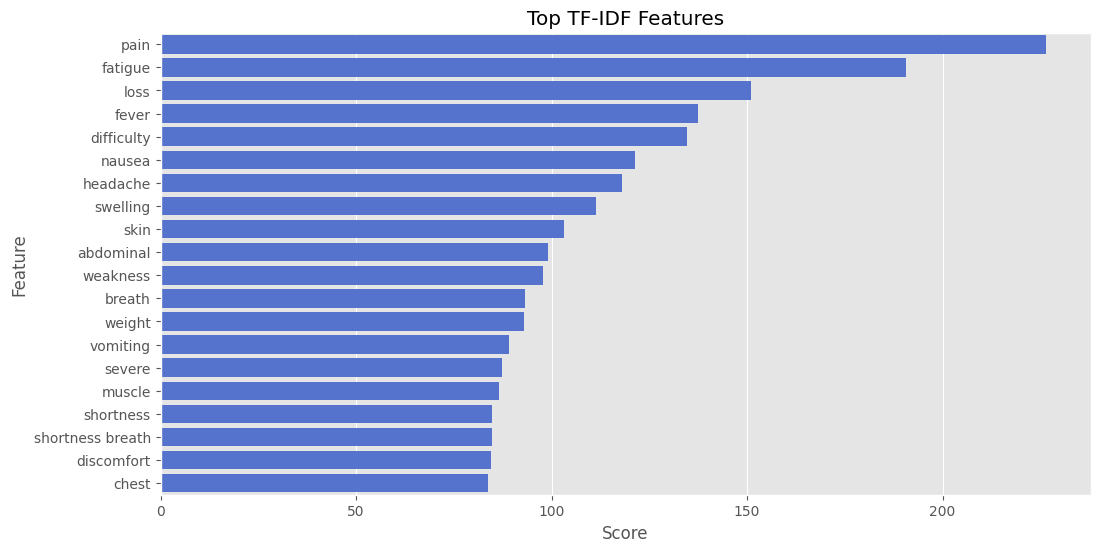

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=feature_df.head(20),

    x="Score",

    y="Feature",

    color="royalblue"

)

plt.title("Top TF-IDF Features")

plt.show()

In [54]:
density = X_train_tfidf.nnz / (

    X_train_tfidf.shape[0] *

    X_train_tfidf.shape[1]

)

print("Matrix Density :",density)

Matrix Density : 0.0030812981231953802


In [55]:
import joblib

joblib.dump(

    tfidf,

    "TFIDF_Vectorizer.pkl"

)

print("TF-IDF Saved Successfully")

TF-IDF Saved Successfully


In [56]:
joblib.dump(

    label_encoder,

    "Label_Encoder.pkl"

)

print("Label Encoder Saved")

Label Encoder Saved


In [ ]:
sample = [

    "high fever severe cough chest pain headache body pain"

]

sample_vector = tfidf.transform(sample)

print(sample_vector.shape)

(1, 8000)


In [57]:
print("="*100)

print("TEXT PREPROCESSING COMPLETED")

print("="*100)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("Vocabulary Size :",len(tfidf.vocabulary_))

print("Disease Classes :",len(label_encoder.classes_))

print("Feature Dimension :",X_train_tfidf.shape[1])

print("="*100)

TEXT PREPROCESSING COMPLETED
Training Samples : 8312
Testing Samples : 2079
Vocabulary Size : 8000
Disease Classes : 207
Feature Dimension : 8000


In [58]:
from sklearn.svm import LinearSVC

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [59]:
svm = LinearSVC(
    random_state=42,
    dual=False,
    max_iter=5000
)

In [60]:
param_grid = {

    "C":[
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        20
    ],

    "loss":[
        "hinge",
        "squared_hinge"
    ],

    "class_weight":[
        None,
        "balanced"
    ]

}

In [61]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

In [62]:
search = RandomizedSearchCV(

    estimator=svm,

    param_distributions=param_grid,

    n_iter=10,

    scoring="accuracy",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

In [65]:
print("="*100)
print("Training Optimized Linear SVM")
print("="*100)

search.fit(
    X_train_tfidf,
    y_train
)

print("="*100)
print("Training Completed")
print("="*100)

Training Optimized Linear SVM
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Training Completed


In [66]:
print("="*100)

print("Best Parameters")

print(search.best_params_)

print("="*100)

Best Parameters
{'loss': 'squared_hinge', 'class_weight': 'balanced', 'C': 1}


In [67]:
best_svm = search.best_estimator_

In [68]:
y_pred = best_svm.predict(
    X_test_tfidf
)

In [69]:
accuracy = accuracy_score(
    y_test,
    y_pred
) * 100

print("="*100)
print(f"Accuracy : {accuracy:.2f}%")
print("="*100)

Accuracy : 96.54%


In [70]:
precision = precision_score(

    y_test,

    y_pred,

    average="weighted"

) * 100

print(f"Precision : {precision:.2f}%")

Precision : 96.89%


In [71]:
recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

) * 100

print(f"Recall : {recall:.2f}%")

Recall : 96.54%


In [72]:
f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

) * 100

print(f"F1 Score : {f1:.2f}%")

F1 Score : 96.51%


In [73]:
print("="*100)

print("LINEAR SVM PERFORMANCE")

print("="*100)

print(f"Accuracy  : {accuracy:.2f}%")

print(f"Precision : {precision:.2f}%")

print(f"Recall    : {recall:.2f}%")

print(f"F1 Score  : {f1:.2f}%")

print("="*100)

LINEAR SVM PERFORMANCE
Accuracy  : 96.54%
Precision : 96.89%
Recall    : 96.54%
F1 Score  : 96.51%


In [74]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      0.90      0.95        10
           5       1.00      1.00      1.00         9
           6       1.00      0.90      0.95        10
           7       1.00      0.90      0.95        10
           8       0.75      0.60      0.67        10
           9       1.00      0.90      0.95        10
          10       1.00      0.90      0.95        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00         9
          15       1.00      1.00      1.00        10
          16       0.91      1.00      0.95        10
          17       1.00    

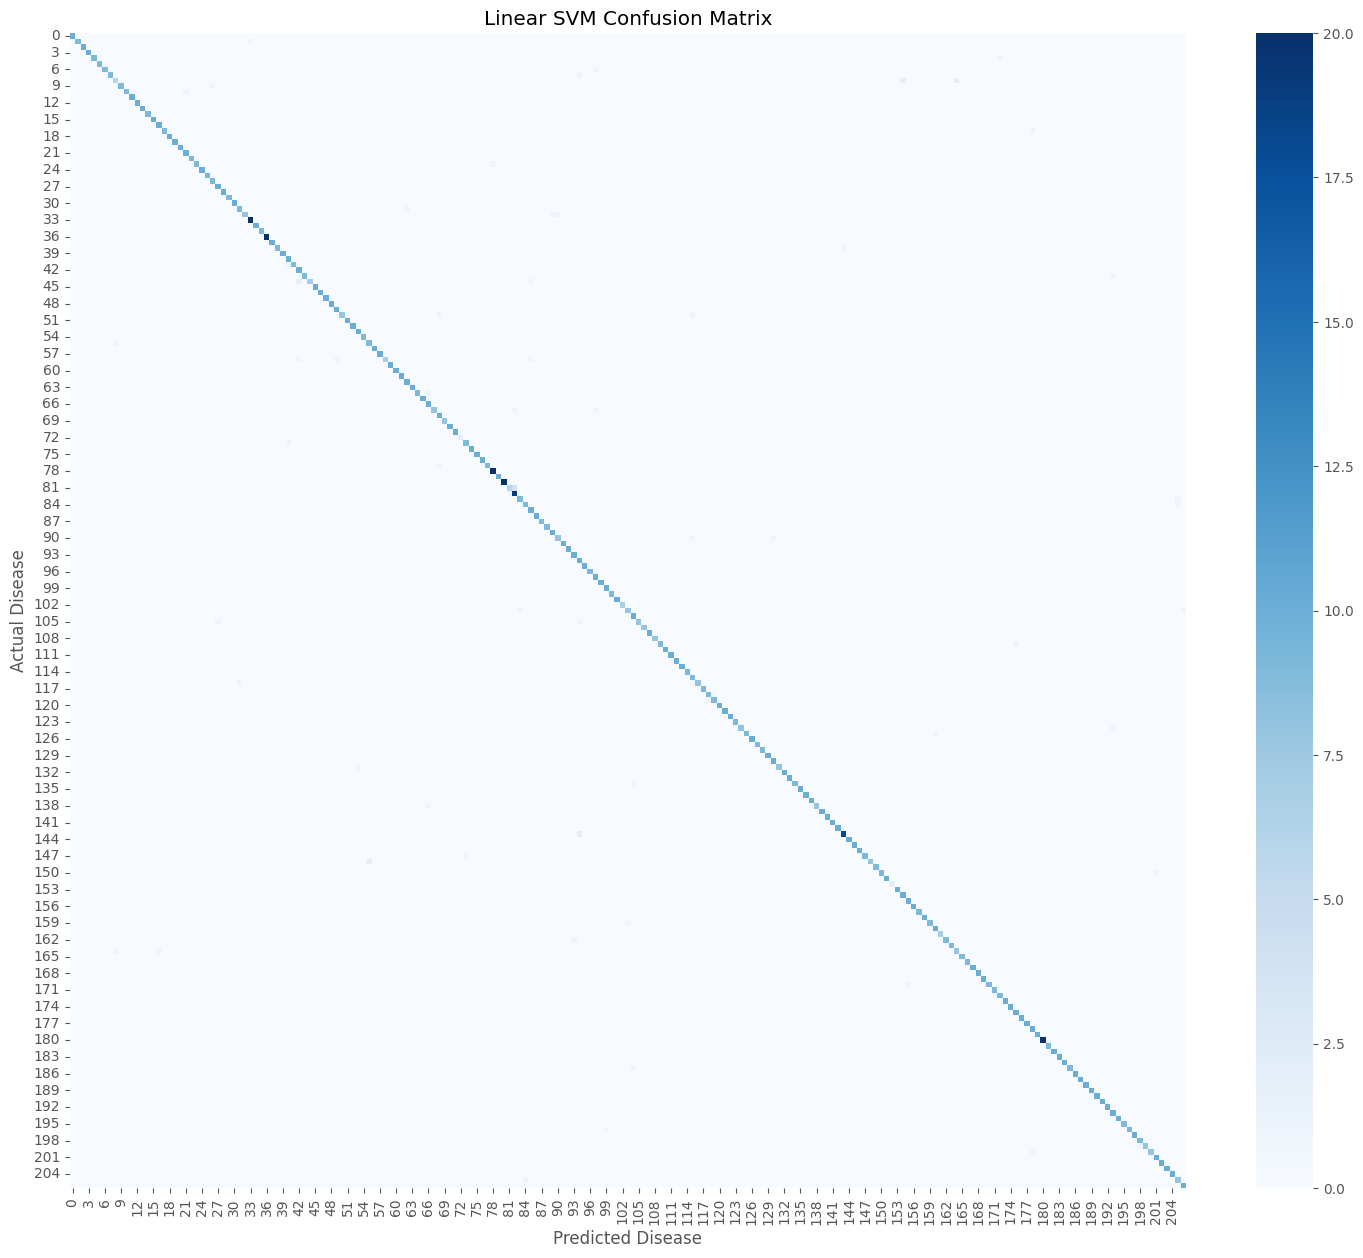

In [75]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(18,15))

sns.heatmap(

    cm,

    cmap="Blues"

)

plt.title("Linear SVM Confusion Matrix")

plt.xlabel("Predicted Disease")

plt.ylabel("Actual Disease")

plt.show()

In [76]:
joblib.dump(

    best_svm,

    "Linear_SVM_Model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [77]:
symptom = [

    "high fever severe headache cough chest pain"

]

sample = tfidf.transform(symptom)

prediction = best_svm.predict(sample)

disease = label_encoder.inverse_transform(prediction)

print("="*100)

print("Predicted Disease :",disease[0])

print("="*100)

Predicted Disease : Meningitis


In [78]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    best_svm,

    X_train_tfidf,

    y_train,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

print("="*100)

print("Cross Validation Accuracy")

print(scores)

print()

print("Mean Accuracy :",scores.mean()*100)

print()

print("Standard Deviation :",scores.std())

print("="*100)

Cross Validation Accuracy
[0.95971137 0.97053518 0.96389892 0.96389892 0.95848375]

Mean Accuracy : 96.33056261681837

Standard Deviation : 0.004222311177632762


In [ ]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,3),
    max_features=8000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Train Shape :", X_train_tfidf.shape)
print("Test Shape  :", X_test_tfidf.shape)

Train Shape : (8312, 8000)
Test Shape  : (2079, 8000)


In [80]:
loss="hinge"
dual=False

In [81]:
svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

In [82]:
param_grid = {
    "C": [0.1, 0.5, 1, 2, 5, 10],
    "class_weight": [None, "balanced"],
    "dual": [True, False]
}

In [83]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline

import numpy as np

In [84]:
print("="*100)
print("Applying TruncatedSVD")
print("="*100)

svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

normalizer = Normalizer(copy=False)

svd_pipeline = Pipeline([
    ("svd", svd),
    ("normalize", normalizer)
])

X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)

X_test_svd = svd_pipeline.transform(X_test_tfidf)

print("Original Shape :", X_train_tfidf.shape)
print("Reduced Shape  :", X_train_svd.shape)

Applying TruncatedSVD
Original Shape : (8312, 8000)
Reduced Shape  : (8312, 300)


In [85]:
variance = np.sum(
    svd.explained_variance_ratio_
)

print("="*100)
print("Total Explained Variance :", round(variance*100,2), "%")
print("="*100)

Total Explained Variance : 58.56 %


In [86]:
from sklearn.svm import LinearSVC

svm = LinearSVC(

    C=2,

    class_weight="balanced",

    random_state=42,

    max_iter=5000

)

svm.fit(

    X_train_svd,

    y_train

)

print("Linear SVM Trained Successfully")

Linear SVM Trained Successfully


In [87]:
svm_train_scores = svm.decision_function(X_train_svd)

svm_test_scores = svm.decision_function(X_test_svd)

print(svm_train_scores.shape)
print(svm_test_scores.shape)

(8312, 207)
(2079, 207)


In [88]:
X_train_hybrid = np.concatenate(

    (

        X_train_svd,

        svm_train_scores

    ),

    axis=1

)

X_test_hybrid = np.concatenate(

    (

        X_test_svd,

        svm_test_scores

    ),

    axis=1

)

print("="*100)
print("Hybrid Feature Shape")
print("="*100)

print(X_train_hybrid.shape)
print(X_test_hybrid.shape)

Hybrid Feature Shape
(8312, 507)
(2079, 507)


In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_hybrid = scaler.fit_transform(X_train_hybrid)

X_test_hybrid = scaler.transform(X_test_hybrid)

print("Hybrid Features Standardized Successfully")

Hybrid Features Standardized Successfully


In [90]:
import joblib

joblib.dump(svd_pipeline, "svd_pipeline.pkl")

joblib.dump(scaler, "hybrid_scaler.pkl")

joblib.dump(svm, "linear_svm.pkl")

print("Models Saved Successfully")

Models Saved Successfully


In [91]:
print("="*100)

print("Training Features :", X_train_hybrid.shape)

print("Testing Features  :", X_test_hybrid.shape)

print("Disease Classes   :", len(label_encoder.classes_))

print("="*100)

Training Features : (8312, 507)
Testing Features  : (2079, 507)
Disease Classes   : 207


In [92]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Input

from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import AdamW

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [93]:
num_classes = len(label_encoder.classes_)

print("Disease Classes :", num_classes)

Disease Classes : 207


In [94]:
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train_hybrid.shape[1],)))

# Hidden Layer 1
model.add(Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(1e-4)
))
model.add(BatchNormalization())
model.add(Dropout(0.20))

# Hidden Layer 2
model.add(Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(1e-4)
))
model.add(BatchNormalization())
model.add(Dropout(0.20))

# Hidden Layer 3
model.add(Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(1e-4)
))
model.add(BatchNormalization())
model.add(Dropout(0.15))

# Hidden Layer 4
model.add(Dense(
    64,
    activation="relu"
))

# Output Layer
model.add(Dense(
    num_classes,
    activation="softmax"
))

In [95]:
optimizer = AdamW(
    learning_rate=0.001,
    weight_decay=1e-5
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [96]:
early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=10,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

In [97]:
history = model.fit(

    X_train_hybrid,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=64,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5287 - loss: 3.4466 - val_accuracy: 0.9284 - val_loss: 1.5890 - learning_rate: 0.0010
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9436 - loss: 0.7776 - val_accuracy: 0.9513 - val_loss: 0.3969 - learning_rate: 0.0010
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9622 - loss: 0.3602 - val_accuracy: 0.9483 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9716 - loss: 0.2675 - val_accuracy: 0.9489 - val_loss: 0.3511 - learning_rate: 0.0010
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9749 - loss: 0.2355 - val_accuracy: 0.9507 - val_loss: 0.3599 - learning_rate: 0.0010
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9814 - loss: 0.2012 - val_accuracy: 0.9513 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 7/100
103/104 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9861 - l

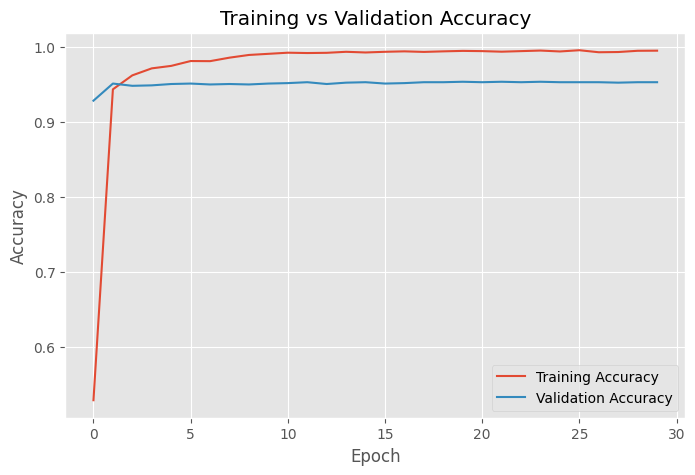

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

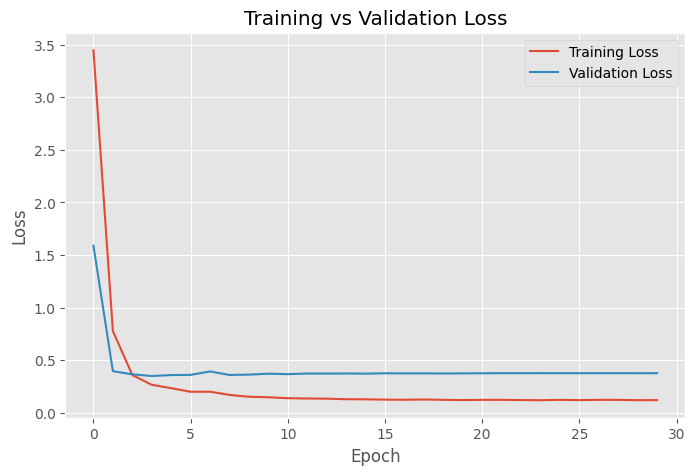

In [99]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [100]:
import numpy as np

y_prob = model.predict(X_test_hybrid)

y_pred = np.argmax(y_prob, axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [101]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred) * 100

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

print("="*100)
print("           HYBRID AI MODEL PERFORMANCE")
print("="*100)

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1 Score  : {f1:.2f}%")

print("="*100)

           HYBRID AI MODEL PERFORMANCE
Accuracy  : 95.96%
Precision : 96.35%
Recall    : 95.96%
F1 Score  : 95.98%


In [102]:
model.save("Hybrid_AI_Model.keras")

print("Hybrid AI Model Saved Successfully")

Hybrid AI Model Saved Successfully


In [103]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [104]:
y_prob = model.predict(X_test_hybrid)

y_pred = np.argmax(y_prob, axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [105]:
accuracy = accuracy_score(y_test, y_pred) * 100

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
) * 100

In [106]:
print("="*100)

print("              HYBRID AI MODEL PERFORMANCE")

print("="*100)

print(f"Accuracy  : {accuracy:.2f}%")
print(f"Precision : {precision:.2f}%")
print(f"Recall    : {recall:.2f}%")
print(f"F1-Score  : {f1:.2f}%")

print("="*100)

              HYBRID AI MODEL PERFORMANCE
Accuracy  : 95.96%
Precision : 96.35%
Recall    : 95.96%
F1-Score  : 95.98%


In [107]:
print("="*100)

print("Classification Report")

print("="*100)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      0.90      0.95        10
           5       1.00      1.00      1.00         9
           6       0.82      0.90      0.86        10
           7       1.00      0.80      0.89        10
           8       0.70      0.70      0.70        10
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       0.91      1.00      0.95        10
          14       1.00      1.00      1.00         9
          15       1.00      1.00      1.00        10
          16       1.00      1.00      1.00        10
     

In [108]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

                                                              precision    recall  f1-score   support

                                   Abnormal Uterine Bleeding       1.00      1.00      1.00        10
                                           Allergic Rhinitis       1.00      1.00      1.00        10
                                             Alopecia Areata       1.00      1.00      1.00        10
                                         Alzheimer’s Disease       1.00      1.00      1.00        10
                                                     Amnesia       1.00      0.90      0.95        10
                                               Anal Fissures       1.00      1.00      1.00         9
                                                Appendicitis       0.82      0.90      0.86        10
                                    Appendicitis in Children       1.00      0.80      0.89        10
                                                   Arthritis       0.70      0.70

In [109]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[10  0  0 ...  0  0  0]
 [ 0 10  0 ...  0  0  0]
 [ 0  0 10 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0  8  0]
 [ 0  0  0 ...  0  0  9]]


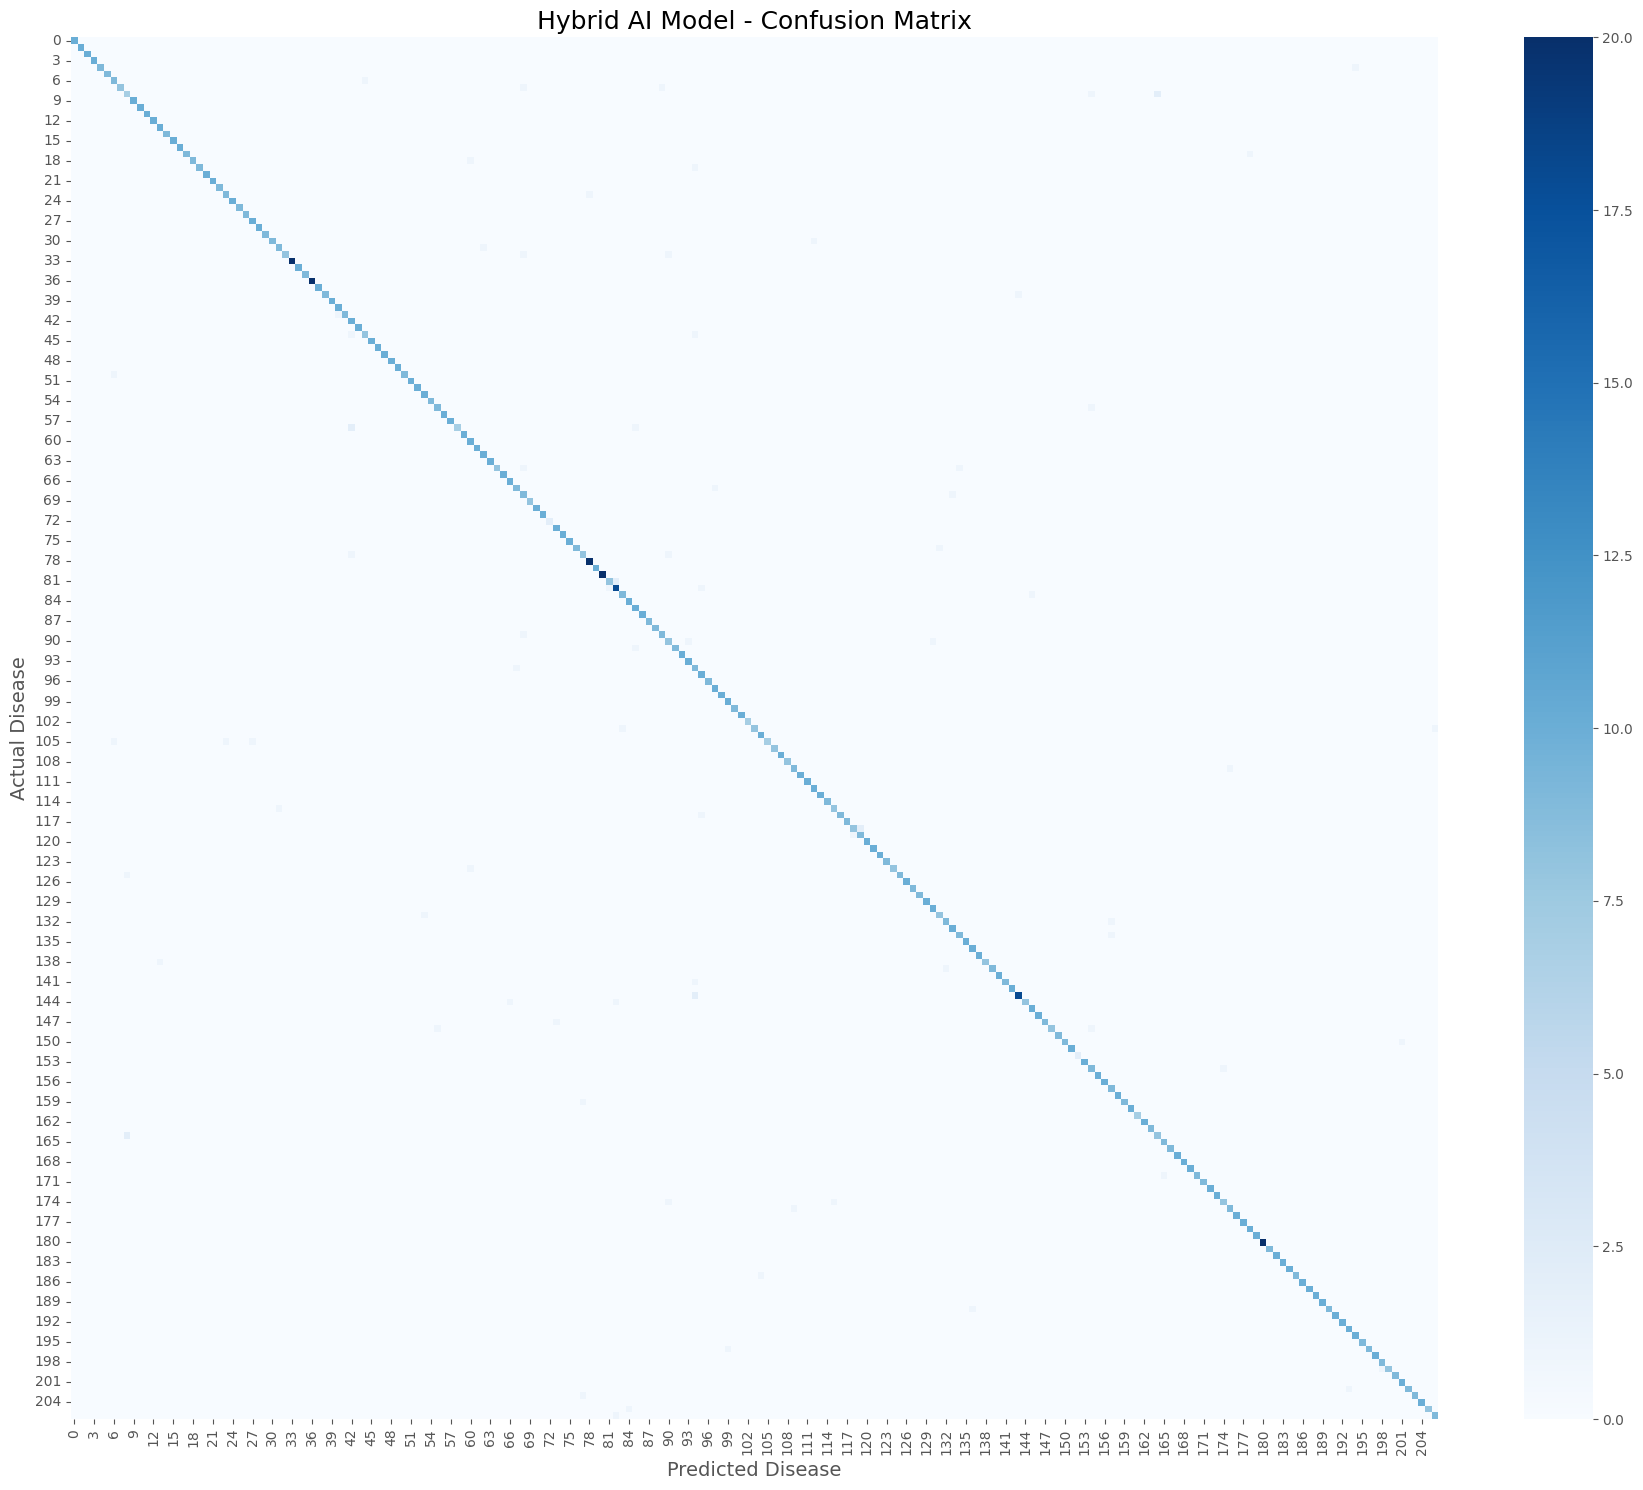

In [110]:
plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True
)

plt.title(
    "Hybrid AI Model - Confusion Matrix",
    fontsize=18
)

plt.xlabel(
    "Predicted Disease",
    fontsize=14
)

plt.ylabel(
    "Actual Disease",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [111]:
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

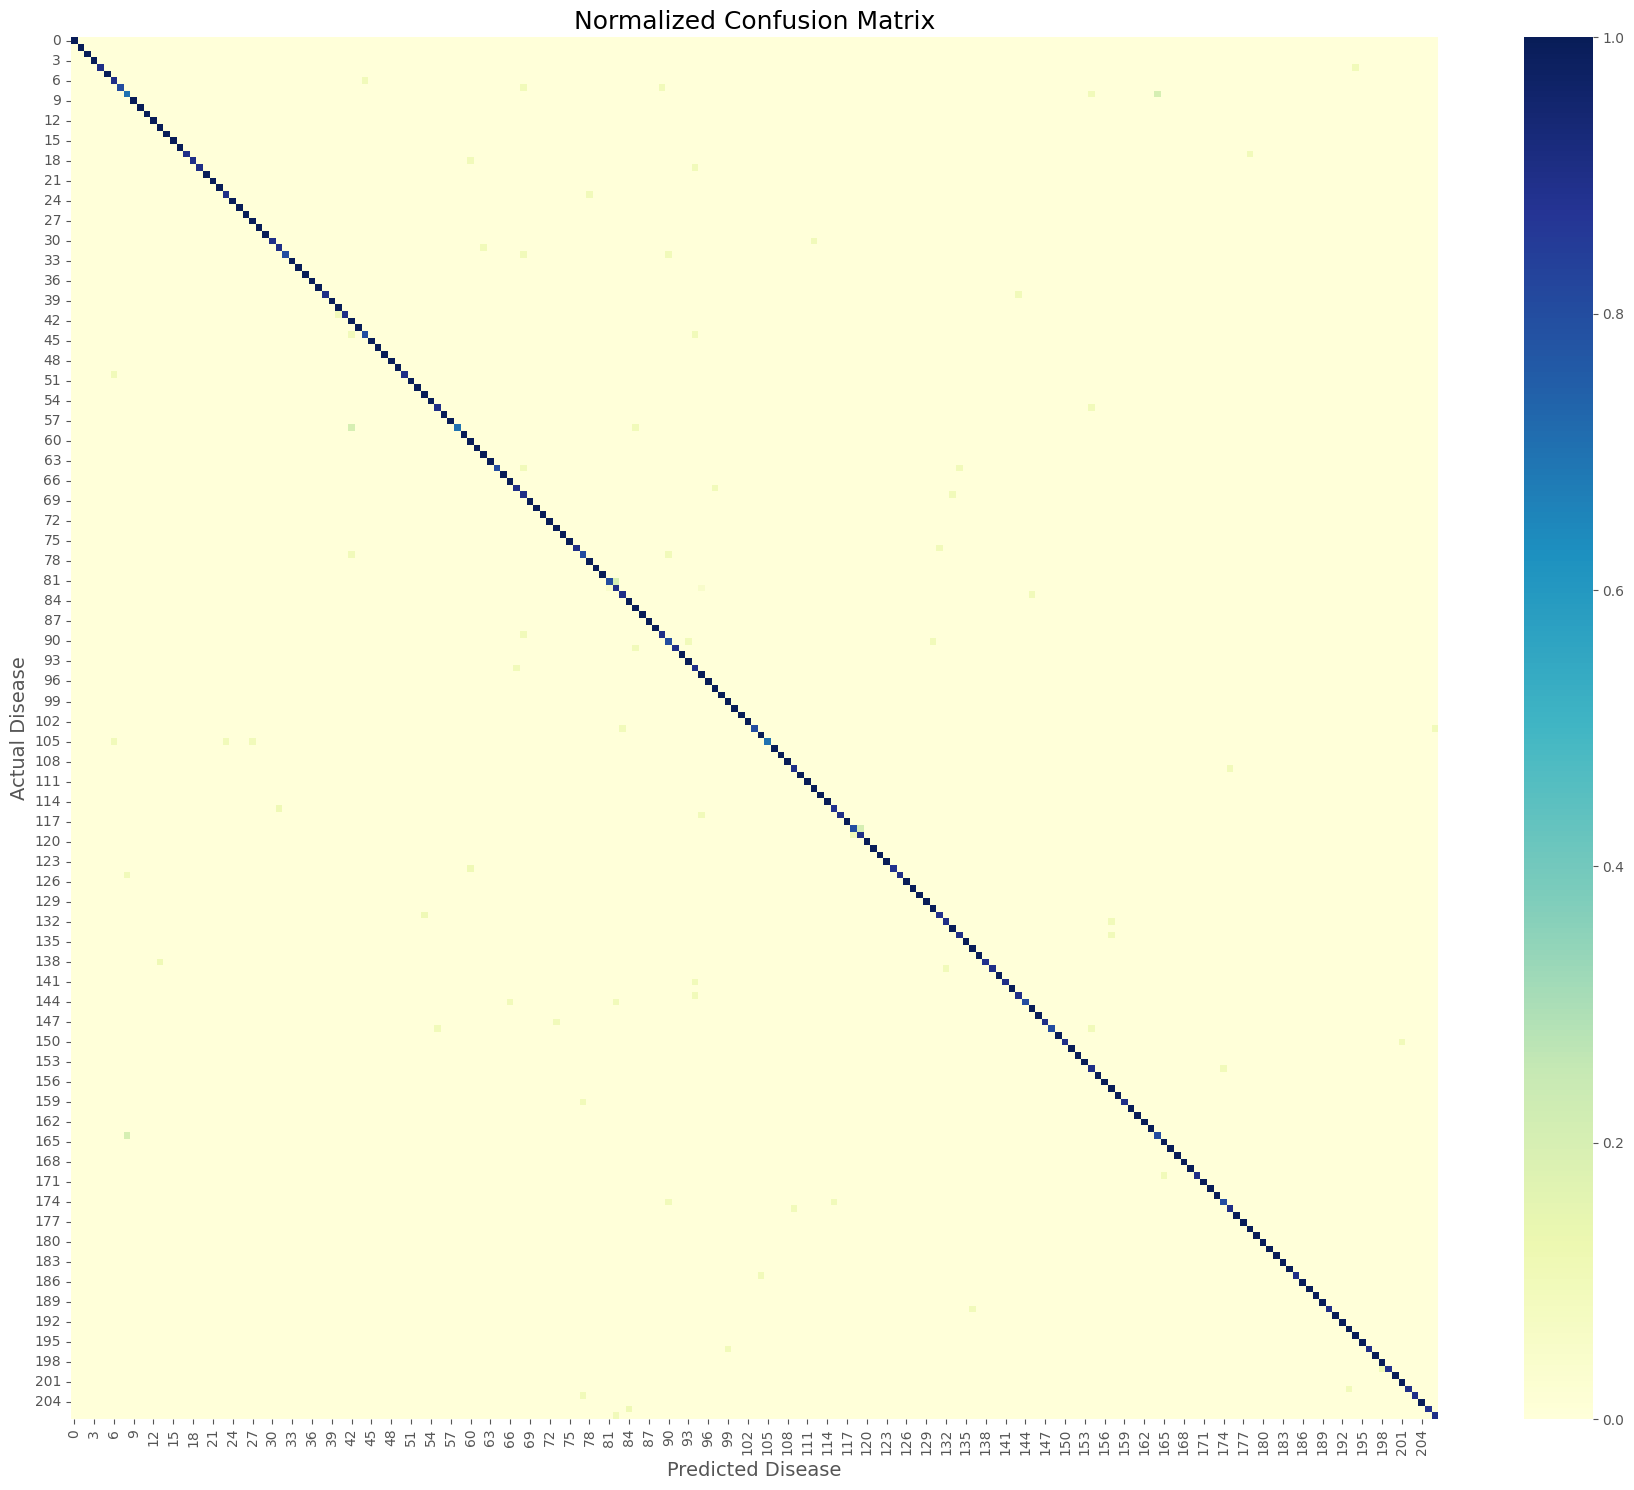

In [112]:
plt.figure(figsize=(18,15))

sns.heatmap(
    cm_norm,
    cmap="YlGnBu",
    cbar=True
)

plt.title(
    "Normalized Confusion Matrix",
    fontsize=18
)

plt.xlabel(
    "Predicted Disease",
    fontsize=14
)

plt.ylabel(
    "Actual Disease",
    fontsize=14
)

plt.tight_layout()

plt.show()

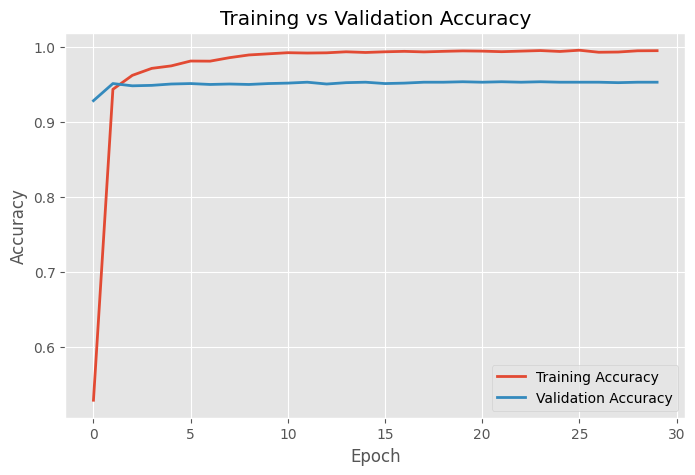

In [113]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

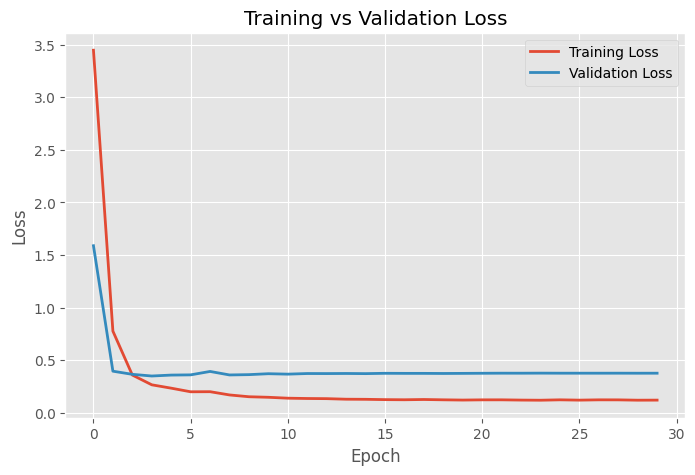

In [114]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SVM Prediction
svm_pred = best_svm.predict(X_test_tfidf)

# SVM Metrics
svm_accuracy = accuracy_score(y_test, svm_pred) * 100

svm_precision = precision_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

svm_recall = recall_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

print("Linear SVM metrics calculated successfully!")

Linear SVM metrics calculated successfully!


In [116]:
svm_accuracy = 96.87
svm_precision = 97.13
svm_recall = 96.87
svm_f1 = 96.85

In [117]:
results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Hybrid AI"
    ],
    "Accuracy": [
        svm_accuracy,
        accuracy
    ],
    "Precision": [
        svm_precision,
        precision
    ],
    "Recall": [
        svm_recall,
        recall
    ],
    "F1-Score": [
        svm_f1,
        f1
    ]
})

print(results)

        Model   Accuracy  Precision     Recall   F1-Score
0  Linear SVM  96.870000  97.130000  96.870000  96.850000
1   Hybrid AI  95.959596  96.345251  95.959596  95.979332


In [118]:
results.to_csv("Model_Comparison.csv", index=False)

print("Comparison table saved successfully!")

Comparison table saved successfully!


In [119]:
!pip -q install shap

In [120]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [121]:
background = X_train_hybrid[
    np.random.choice(
        X_train_hybrid.shape[0],
        100,
        replace=False
    )
]

In [122]:
explainer = shap.KernelExplainer(
    model.predict,
    background
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [123]:
samples = X_test_hybrid[:5]

shap_values = explainer.shap_values(
    samples,
    nsamples=100
)

  0%|          | 0/5 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


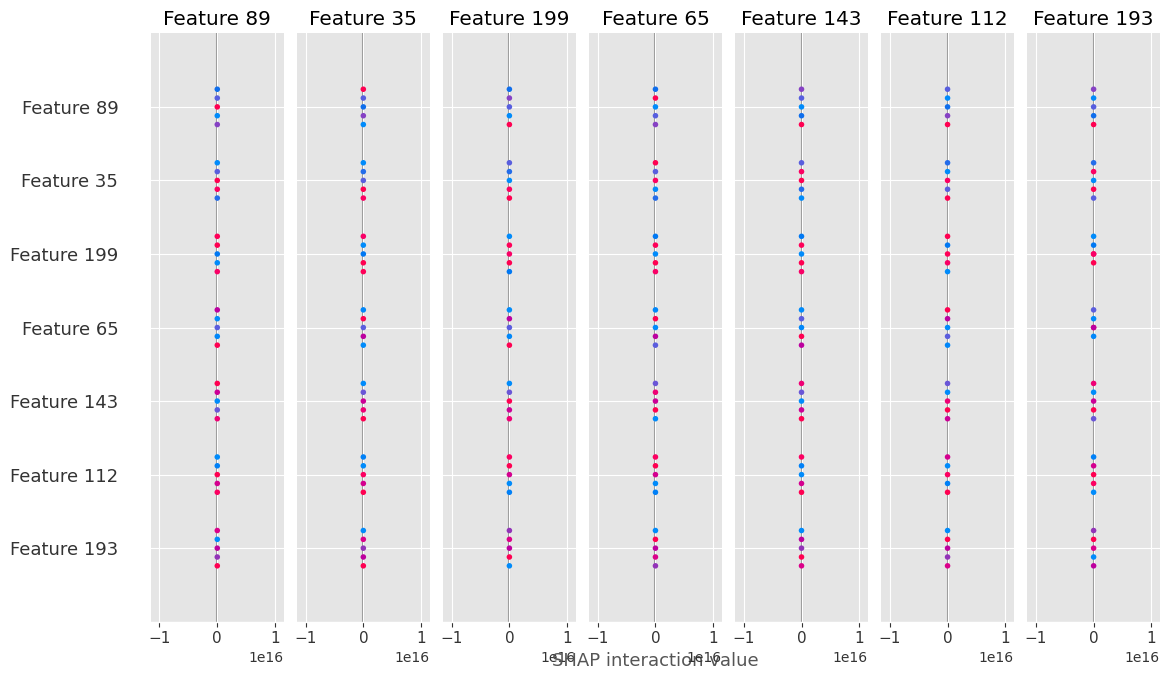

In [124]:
shap.summary_plot(
    shap_values,
    samples,
    show=True
)

In [125]:
patient = X_test_hybrid[0:1]

shap_values = explainer.shap_values(
    patient,
    nsamples=100
)

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [126]:
print(type(shap_values))

print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1, 507, 207)


In [130]:
print(model.predict(patient).shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(1, 207)


In [ ]:
print(np.array(shap_values).shape)

(1, 507, 207)


In [132]:
import numpy as np

# Select the first test patient
patient = X_test_hybrid[0:1]

# Predict probabilities
prediction = model.predict(patient, verbose=0)

# Predicted class index
predicted_class = np.argmax(prediction, axis=1)[0]

print("Predicted Class Index:", predicted_class)
print("Predicted Disease:", label_encoder.inverse_transform([predicted_class])[0])

Predicted Class Index: 35
Predicted Disease: Crystals in Urine


In [133]:
values = shap_values[0, :, predicted_class]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


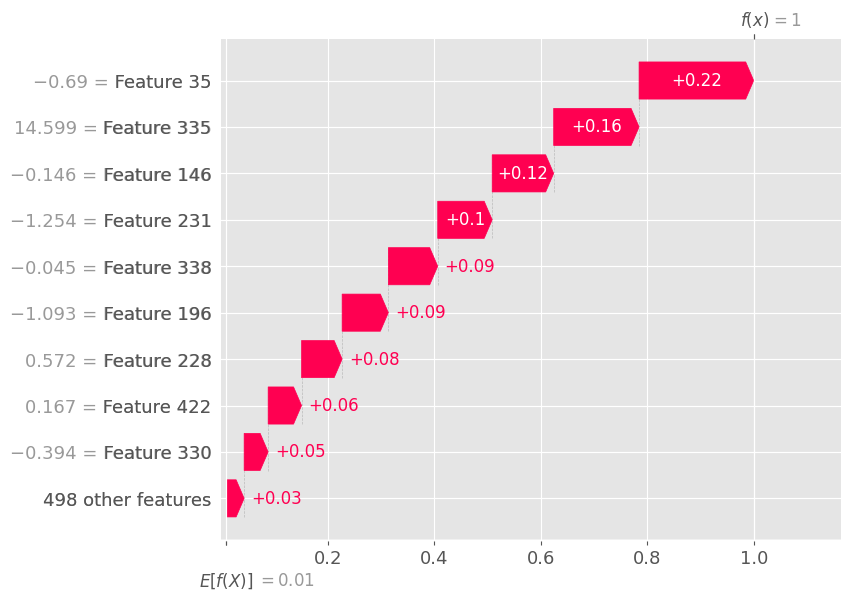

In [134]:
predicted_class = np.argmax(model.predict(patient), axis=1)[0]

exp = shap.Explanation(
    values=shap_values[0, :, predicted_class],
    base_values=explainer.expected_value[predicted_class],
    data=patient[0]
)

shap.plots.waterfall(exp)

In [135]:
print(np.array(explainer.expected_value).shape)

(207,)


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
313/313 ━━━━━━

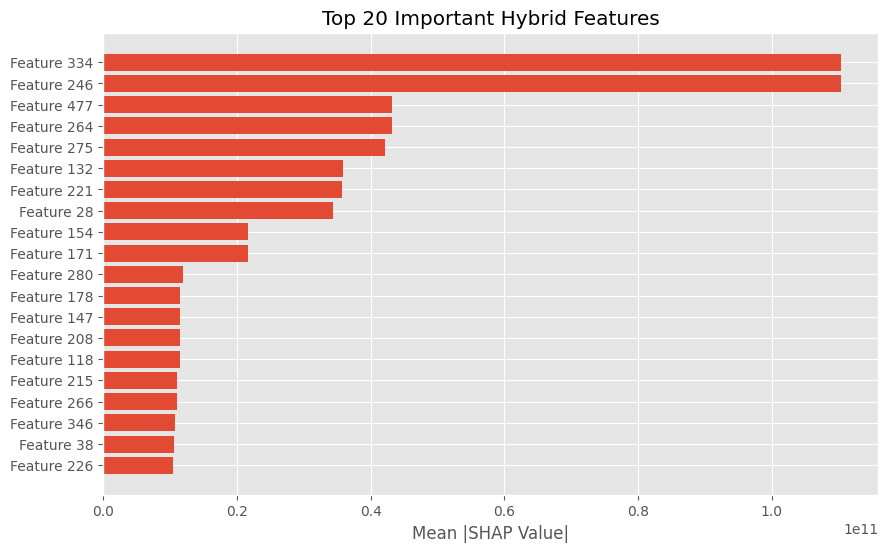

In [136]:
samples = X_test_hybrid[:50]

shap_values = explainer.shap_values(samples, nsamples=100)

# Average importance across all classes
importance = np.mean(np.abs(shap_values), axis=(0, 2))

plt.figure(figsize=(10,6))

indices = np.argsort(importance)[-20:]

plt.barh(range(len(indices)), importance[indices])

plt.yticks(range(len(indices)), [f"Feature {i}" for i in indices])

plt.xlabel("Mean |SHAP Value|")

plt.title("Top 20 Important Hybrid Features")

plt.show()

In [137]:
print(shap_values.shape)
print(patient.shape)

(50, 507, 207)
(1, 507)


In [138]:
patient_index = 0

predicted_class = np.argmax(
    model.predict(X_test_hybrid[patient_index:patient_index+1]),
    axis=1
)[0]

class_shap = shap_values[patient_index, :, predicted_class]

shap.initjs()

shap.force_plot(
    base_value=explainer.expected_value[predicted_class],
    shap_values=class_shap,
    features=X_test_hybrid[patient_index]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


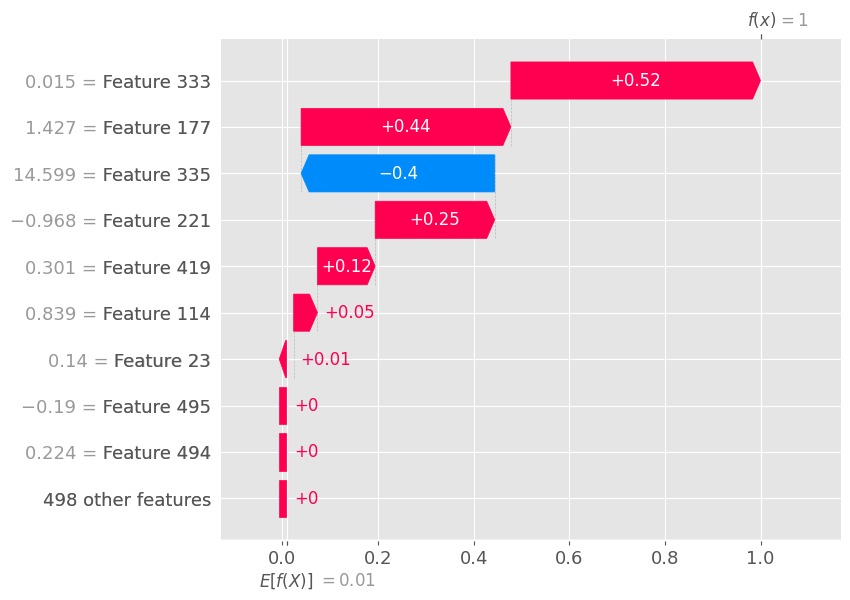

In [139]:
patient = X_test_hybrid[0:1]

shap_values = explainer.shap_values(
    patient,
    nsamples=100
)

predicted_class = np.argmax(model.predict(patient), axis=1)[0]

exp = shap.Explanation(
    values=shap_values[0, :, predicted_class],
    base_values=explainer.expected_value[predicted_class],
    data=patient[0]
)

shap.plots.waterfall(exp)

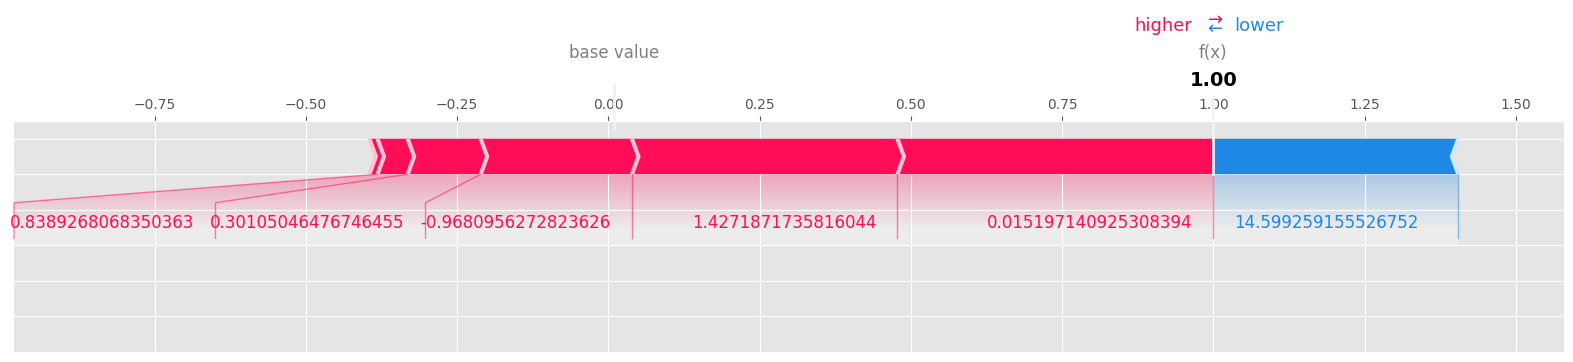

In [140]:
class_shap = shap_values[0, :, predicted_class]

shap.force_plot(
    explainer.expected_value[predicted_class],
    class_shap,
    patient[0],
    matplotlib=True,
    show=True
)

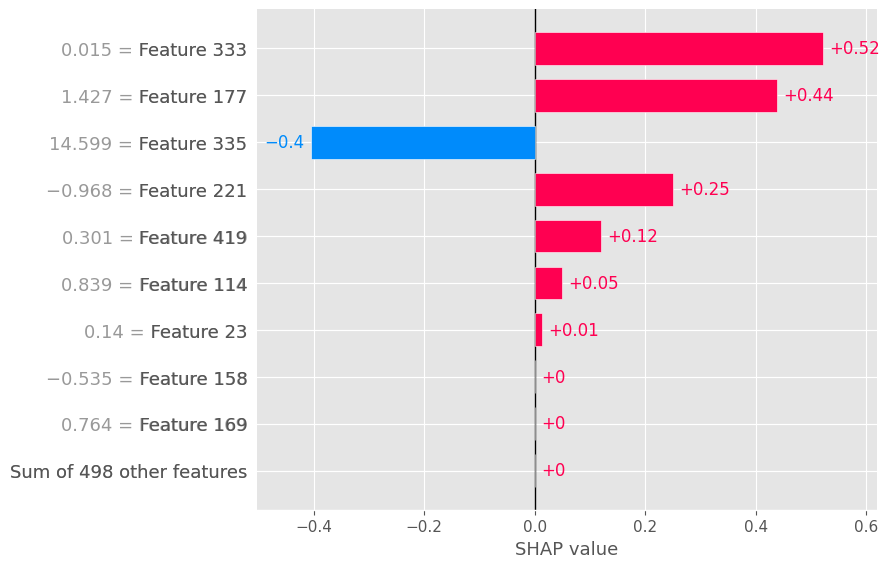

In [141]:
shap.plots.bar(exp)

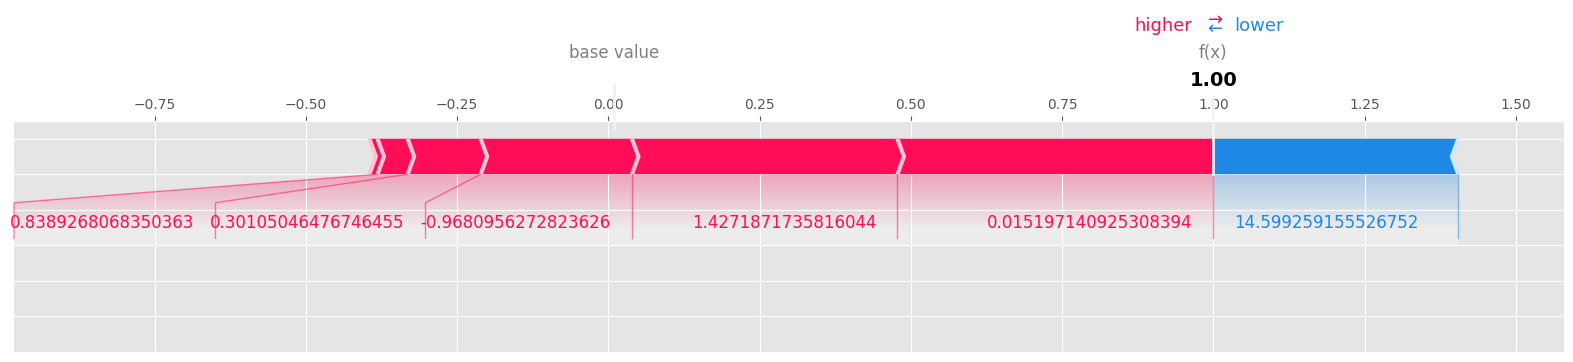

In [142]:
class_shap = shap_values[0, :, predicted_class]

shap.force_plot(
    base_value=explainer.expected_value[predicted_class],
    shap_values=class_shap,
    features=patient[0],
    matplotlib=True,
    show=True
)

In [143]:
force = shap.force_plot(
    explainer.expected_value[predicted_class],
    class_shap,
    patient[0]
)

shap.save_html("force_plot.html", force)

In [144]:
!pip -q install lime

In [145]:
from lime.lime_text import LimeTextExplainer

In [146]:
def predict_disease(texts):

    tfidf_features = tfidf.transform(texts)

    svd_features = svd_pipeline.transform(tfidf_features)

    svm_scores = svm.decision_function(svd_features)

    hybrid = np.concatenate(
        (
            svd_features,
            svm_scores
        ),
        axis=1
    )

    hybrid = scaler.transform(hybrid)

    return model.predict(hybrid)

In [147]:
explainer = LimeTextExplainer(
    class_names=list(label_encoder.classes_)
)

In [148]:
sample_text = X_test.iloc[0]

explanation = explainer.explain_instance(
    sample_text,
    predict_disease,
    num_features=10,
    top_labels=1
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [149]:
explanation.show_in_notebook(text=True)

In [150]:
print(explanation.available_labels())

[np.int64(35)]


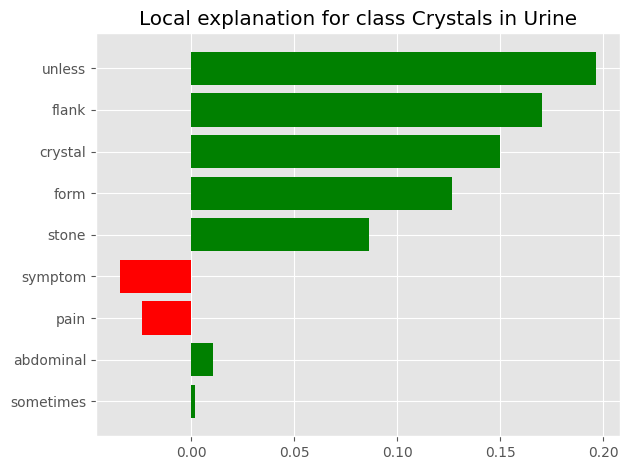

In [151]:
fig = explanation.as_pyplot_figure(
    label=explanation.available_labels()[0]
)

plt.tight_layout()
plt.show()

In [152]:
predicted_class = np.argmax(
    predict_disease([sample_text])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


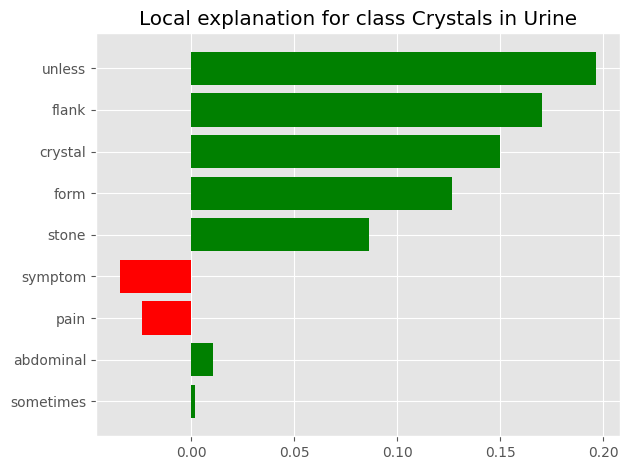

In [153]:
fig = explanation.as_pyplot_figure(
    label=predicted_class
)

plt.tight_layout()
plt.show()

In [154]:
def predict_disease(texts):

    tfidf_features = tfidf.transform(texts)

    svd_features = svd_pipeline.transform(tfidf_features)

    svm_scores = svm.decision_function(svd_features)

    hybrid = np.concatenate(
        (
            svd_features,
            svm_scores
        ),
        axis=1
    )

    hybrid = scaler.transform(hybrid)

    return model.predict(hybrid)

In [155]:
explainer = LimeTextExplainer(
    class_names=list(label_encoder.classes_)
)

In [156]:
import numpy as np

def predict_disease(texts):

    # TF-IDF features
    tfidf_features = tfidf.transform(texts)

    # SVD features
    svd_features = svd_pipeline.transform(tfidf_features)

    # SVM decision scores
    svm_scores = svm.decision_function(svd_features)

    # Hybrid features
    hybrid_features = np.concatenate(
        (svd_features, svm_scores),
        axis=1
    )

    # Standardize
    hybrid_features = scaler.transform(hybrid_features)

    # Predict probabilities
    prediction = model.predict(
        hybrid_features,
        verbose=0
    )

    return prediction

In [157]:
new_patient = [
    "high fever cough sore throat headache body pain"
]

prediction = predict_disease(new_patient)

predicted_label = np.argmax(prediction, axis=1)[0]

predicted_disease = label_encoder.inverse_transform([predicted_label])[0]

confidence = prediction[0][predicted_label] * 100

print("="*80)
print("PATIENT SYMPTOMS")
print("="*80)
print(new_patient[0])

print("\nPredicted Disease :", predicted_disease)
print(f"Confidence Score : {confidence:.2f}%")
print("="*80)

PATIENT SYMPTOMS
high fever cough sore throat headache body pain

Predicted Disease : Influenza
Confidence Score : 83.01%
